# Strict Raw-Feature V2 Advanced Contextual Bandit Evaluation

This notebook evaluates Linear Thompson Sampling and LassoLinUCB on the cleaned raw-feature V2 sets. The active LinearTS grid uses diagonal covariance; the full-covariance implementation remains available in code but is not part of the default grid because it was slower and did not improve accuracy. Coefficient audits are saved for the best advanced configurations.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / 'results' / 'v2_advanced_bandits'
AUDIT_DIR = RESULTS_DIR / 'coefficient_audit'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)

Repo root: /Users/dhillo/Garage/codeComplete/full measure/warfarin
Results dir: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits


In [3]:
from src.bandits.lasso_bandit import LassoLinUCB
from src.bandits.linear_thompson_sampling import LinearThompsonSampling
from src.evaluation.advanced_bandit_benchmark import (
    DEFAULT_LASSO_GRID,
    DEFAULT_TS_GRID,
    FINAL_ADVANCED_FEATURE_SETS,
    REWARD_SCHEMES_TO_COMPARE,
    classwise_advanced_metrics,
    combine_advanced_results,
    evaluate_advanced_grid_for_rewards,
    evaluate_lasso_grid,
    evaluate_linear_ts_grid,
    get_intercept_index,
    make_static_baselines_for_feature_sets,
    plot_advanced_leaderboard,
    save_advanced_benchmark,
    summarize_advanced_errors,
)
from src.evaluation.coefficient_audit import (
    audit_bandit_coefficients,
    coefficient_model_card,
    plot_top_coefficients,
    save_coefficient_audit,
    save_coefficient_model_card,
)
from src.evaluation.feature_set_benchmark import available_final_feature_sets, load_v2_assets

## 1. Load cleaned V2 assets and choose feature sets

In [4]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)
selected_feature_sets = available_final_feature_sets(feature_sets, FINAL_ADVANCED_FEATURE_SETS)

print('V2 modeling table:', df_v2.shape)
print('Selected feature sets:', selected_feature_sets)
print('Reward schemes:', REWARD_SCHEMES_TO_COMPARE)

V2 modeling table: (5528, 307)
Selected feature sets: ['v2_strict_regression_hw_full_dummies', 'v2_strict_knn_hw_full_dummies']
Reward schemes: ['binary', 'ordinal']


In [5]:
static_baselines = make_static_baselines_for_feature_sets(df_v2, selected_feature_sets)
static_baselines.to_csv(RESULTS_DIR / 'static_baselines_for_selected_feature_sets.csv', index=False)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])

,feature_set,algorithm,accuracy,fraction_incorrect,mean_ordinal_reward,n_correct,n_total
1,v2_strict_knn_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528
0,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528


## 2. Hyperparameter grids

In [6]:
print('LinearTS grid:')
for row in DEFAULT_TS_GRID:
    print(row)

print('\nLassoLinUCB grid:')
for row in DEFAULT_LASSO_GRID:
    print(row)

LinearTS grid:
{'lambda_reg': 5.0, 'sample_scale': 0.01, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.01, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.025, 'covariance_type': 'diagonal'}
{'lambda_reg': 20.0, 'sample_scale': 0.025, 'covariance_type': 'diagonal'}

LassoLinUCB grid:
{'lasso_alpha': 0.0005, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 15, 'refit_frequency': 50}
{'lasso_alpha': 0.001, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 15, 'refit_frequency': 50}
{'lasso_alpha': 0.0025, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 20, 'refit_frequency': 50}
{'lasso_alpha': 0.001, 'ucb_alpha': 0.025, 'lambda_reg': 10.0, 'min_samples_per_arm': 20, 'refit_frequency': 50}


## 3. Linear Thompson Sampling under both reward schemes

In [7]:
SEEDS = range(3)

ts_summary, ts_results, ts_scale_stats = evaluate_advanced_grid_for_rewards(
    evaluator=evaluate_linear_ts_grid,
    df=df_v2,
    feature_sets=feature_sets,
    bandit_cls=LinearThompsonSampling,
    feature_set_names=selected_feature_sets,
    param_grid=DEFAULT_TS_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ts_summary.head(15)

LinearTS feature set: v2_strict_regression_hw_full_dummies (295 features), reward=binary
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
LinearTS feature set: v2_strict_knn_hw_full_dummies (295 features), reward=binary
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
LinearTS feature set: v2_strict_regression_hw_full_dummies (295 features), reward=ordinal
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
LinearTS feature set: v2_strict_knn_hw_full_dummies (295 features), reward=ordinal
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,final_fraction_incorrect_ci95,late_accuracy_ci95,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type
8,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,3,0.681138,0.000685,0.679088,0.000829,1774.000000,4.582576,0.318862,...,0.000775,0.041997,0.041072,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal
0,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.680897,0.003086,0.680897,0.003086,1764.000000,17.058722,0.319103,...,0.003492,0.032113,0.032113,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",295,5.0,0.010,diagonal
1,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,3,0.680897,0.005283,0.680897,0.005283,1764.000000,29.206164,0.319103,...,0.005979,0.038297,0.038297,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal
9,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,3,0.679993,0.002366,0.678003,0.002352,1780.000000,13.000000,0.320007,...,0.002677,0.043199,0.044484,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal
2,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.679872,0.003040,0.679872,0.003040,1769.666667,16.802778,0.320128,...,0.003440,0.038674,0.038674,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",295,10.0,0.010,diagonal
3,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,3,0.679149,0.005162,0.679149,0.005162,1773.666667,28.536526,0.320851,...,0.005842,0.043001,0.043001,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal
4,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,3,0.678787,0.003439,0.678787,0.003439,1775.666667,19.008770,0.321213,...,0.003891,0.040232,0.040232,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",295,10.0,0.025,diagonal
10,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.678726,0.001546,0.676556,0.001809,1788.000000,10.000000,0.321274,...,0.001749,0.026683,0.026683,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",295,10.0,0.010,diagonal
11,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,3,0.678003,0.002533,0.675953,0.002262,1791.333333,12.503333,0.321997,...,0.002866,0.034348,0.035377,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",295,10.0,0.025,diagonal
12,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.677641,0.002533,0.675591,0.002089,1793.333333,11.547005,0.322359,...,0.002866,0.033898,0.034249,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",295,10.0,0.010,diagonal


## 4. LassoLinUCB under both reward schemes

In [8]:
lasso_summary, lasso_results, lasso_scale_stats = evaluate_advanced_grid_for_rewards(
    evaluator=evaluate_lasso_grid,
    df=df_v2,
    feature_sets=feature_sets,
    bandit_cls=LassoLinUCB,
    feature_set_names=selected_feature_sets,
    param_grid=DEFAULT_LASSO_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

lasso_summary.head(15)

LassoLinUCB feature set: v2_strict_regression_hw_full_dummies (295 features), reward=binary
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_strict_knn_hw_full_dummies (295 features), reward=binary
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_strict_regression_hw_full_dummies (295 features), reward=ordinal
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, 

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.672214,0.003867,0.672214,0.003867,1812.000000,21.377558,0.327786,...,0.026101,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",295,10.0,0.0025,0.000,20,50
8,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",ordinal,3,0.671913,0.001405,0.667692,0.001436,1837.000000,7.937254,0.328087,...,0.033134,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",295,10.0,0.0025,0.000,20,50
1,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.670224,0.001413,0.670224,0.001413,1823.000000,7.810250,0.329776,...,0.034274,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",295,10.0,0.0025,0.000,20,50
9,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",ordinal,3,0.669682,0.006190,0.665521,0.006347,1849.000000,35.085610,0.330318,...,0.027811,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",295,10.0,0.0025,0.000,20,50
10,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",ordinal,3,0.667451,0.003664,0.661179,0.002911,1873.000000,16.093477,0.332549,...,0.037394,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",295,10.0,0.0010,0.025,20,50
2,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",binary,3,0.667330,0.005448,0.667330,0.005448,1839.000000,30.116441,0.332670,...,0.033898,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",295,10.0,0.0010,0.000,15,50
3,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",binary,3,0.666727,0.002535,0.666727,0.002535,1842.333333,14.011900,0.333273,...,0.030392,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",295,10.0,0.0010,0.000,15,50
11,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",ordinal,3,0.665822,0.005073,0.659370,0.005743,1883.000000,31.749016,0.334178,...,0.037667,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",295,10.0,0.0010,0.000,15,50
12,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",ordinal,3,0.665702,0.004172,0.659732,0.004637,1881.000000,25.632011,0.334298,...,0.027440,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",295,10.0,0.0010,0.000,15,50
13,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",ordinal,3,0.665642,0.006503,0.659370,0.006778,1883.000000,37.469988,0.334358,...,0.027657,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",295,10.0,0.0010,0.025,20,50


## 5. Combined advanced leaderboard

In [9]:
advanced_summary = pd.concat([ts_summary, lasso_summary], ignore_index=True).sort_values(
    'final_accuracy_mean', ascending=False
)
advanced_results = combine_advanced_results(ts_results, lasso_results)
advanced_scale_stats = pd.concat([ts_scale_stats, lasso_scale_stats], ignore_index=True)

advanced_summary.head(25)

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,3,0.681138,0.000685,0.679088,0.000829,1774.000000,4.582576,0.318862,...,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal,NaN,NaN,NaN,NaN
1,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.680897,0.003086,0.680897,0.003086,1764.000000,17.058722,0.319103,...,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",295,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
2,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,3,0.680897,0.005283,0.680897,0.005283,1764.000000,29.206164,0.319103,...,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal,NaN,NaN,NaN,NaN
3,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,3,0.679993,0.002366,0.678003,0.002352,1780.000000,13.000000,0.320007,...,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal,NaN,NaN,NaN,NaN
4,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.679872,0.003040,0.679872,0.003040,1769.666667,16.802778,0.320128,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",295,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
5,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,3,0.679149,0.005162,0.679149,0.005162,1773.666667,28.536526,0.320851,...,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",295,20.0,0.025,diagonal,NaN,NaN,NaN,NaN
6,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,3,0.678787,0.003439,0.678787,0.003439,1775.666667,19.008770,0.321213,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",295,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
7,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.678726,0.001546,0.676556,0.001809,1788.000000,10.000000,0.321274,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",295,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
8,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,3,0.678003,0.002533,0.675953,0.002262,1791.333333,12.503333,0.321997,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",295,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
9,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.677641,0.002533,0.675591,0.002089,1793.333333,11.547005,0.322359,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",295,10.0,0.010,diagonal,NaN,NaN,NaN,NaN


In [10]:
written = save_advanced_benchmark(
    RESULTS_DIR,
    prefix='advanced_bandit',
    summary=advanced_summary,
    results=advanced_results,
    scale_stats=advanced_scale_stats,
    save_step_results=False,
)
written

{'advanced_bandit_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_summary.csv',
 'advanced_bandit_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_error_summary.csv',
 'advanced_bandit_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_classwise.csv',
 'advanced_bandit_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_confusion_true_normalized.csv',
 'advanced_bandit_confusion_counts': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_confusion_counts.csv',
 'advanced_bandit_scale_stats': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_scale_stats.csv'}

## 6. Diagnostics for the best advanced configuration

In [11]:
advanced_error_summary = summarize_advanced_errors(advanced_results)
advanced_error_summary.sort_values('accuracy_mean', ascending=False).head(20)

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,...,mean_regret_mean,mean_regret_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,mean_reward_ci95,severe_error_rate_ci95
29,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,20.0,0.025,diagonal,NaN,NaN,...,0.320912,0.000829,0.002050,0.000209,0.316811,0.161662,0.157200,0.000775,0.000938,0.000236
14,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,5.0,0.010,diagonal,NaN,NaN,...,0.319103,0.003086,0.003256,0.000789,0.315847,0.163049,0.156054,0.003492,0.003492,0.000892
12,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,20.0,0.025,diagonal,NaN,NaN,...,0.319103,0.005283,0.002593,0.000276,0.316510,0.167511,0.151592,0.005979,0.005979,0.000313
13,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,20.0,0.025,diagonal,NaN,NaN,...,0.321997,0.002352,0.001990,0.000181,0.318017,0.165521,0.154486,0.002677,0.002661,0.000205
8,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,10.0,0.010,diagonal,NaN,NaN,...,0.320128,0.003040,0.003316,0.001044,0.316811,0.160818,0.159310,0.003440,0.003440,0.001182
28,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,20.0,0.025,diagonal,NaN,NaN,...,0.320851,0.005162,0.002231,0.001060,0.318620,0.165521,0.155330,0.005842,0.005842,0.001199
10,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)","LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,10.0,0.025,diagonal,NaN,NaN,...,0.321213,0.003439,0.002774,0.001177,0.318439,0.162868,0.158345,0.003891,0.003891,0.001332
25,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,10.0,0.010,diagonal,NaN,NaN,...,0.323444,0.001809,0.002171,0.000313,0.319103,0.165521,0.155753,0.001749,0.002047,0.000355
11,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)","LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,10.0,0.025,diagonal,NaN,NaN,...,0.324047,0.002262,0.002050,0.000276,0.319947,0.161059,0.160938,0.002866,0.002559,0.000313
9,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,10.0,0.010,diagonal,NaN,NaN,...,0.324409,0.002089,0.002050,0.000553,0.320309,0.163591,0.158767,0.002866,0.002364,0.000625


In [12]:
advanced_classwise = classwise_advanced_metrics(advanced_results)
best = advanced_summary.iloc[0]
best_filter = (
    (advanced_classwise['feature_set'] == best['feature_set'])
    & (advanced_classwise['algorithm_family'] == best['algorithm_family'])
    & (advanced_classwise['config_name'] == best['config_name'])
    & (advanced_classwise['reward_scheme'] == best['reward_scheme'])
)
advanced_classwise.loc[best_filter].sort_values('class_id')

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,...,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
87,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,20.0,0.025,diagonal,NaN,NaN,...,3,0.673288,0.009966,0.461315,0.024415,0.547096,0.014265,1495.0,0.027629,0.016143
88,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,20.0,0.025,diagonal,NaN,NaN,...,3,0.687556,0.001383,0.883797,0.005711,0.773413,0.001363,3382.0,0.006462,0.001543
89,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,20.0,0.025,diagonal,NaN,NaN,...,3,0.554908,0.013284,0.133129,0.031192,0.213780,0.040835,651.0,0.035297,0.046209


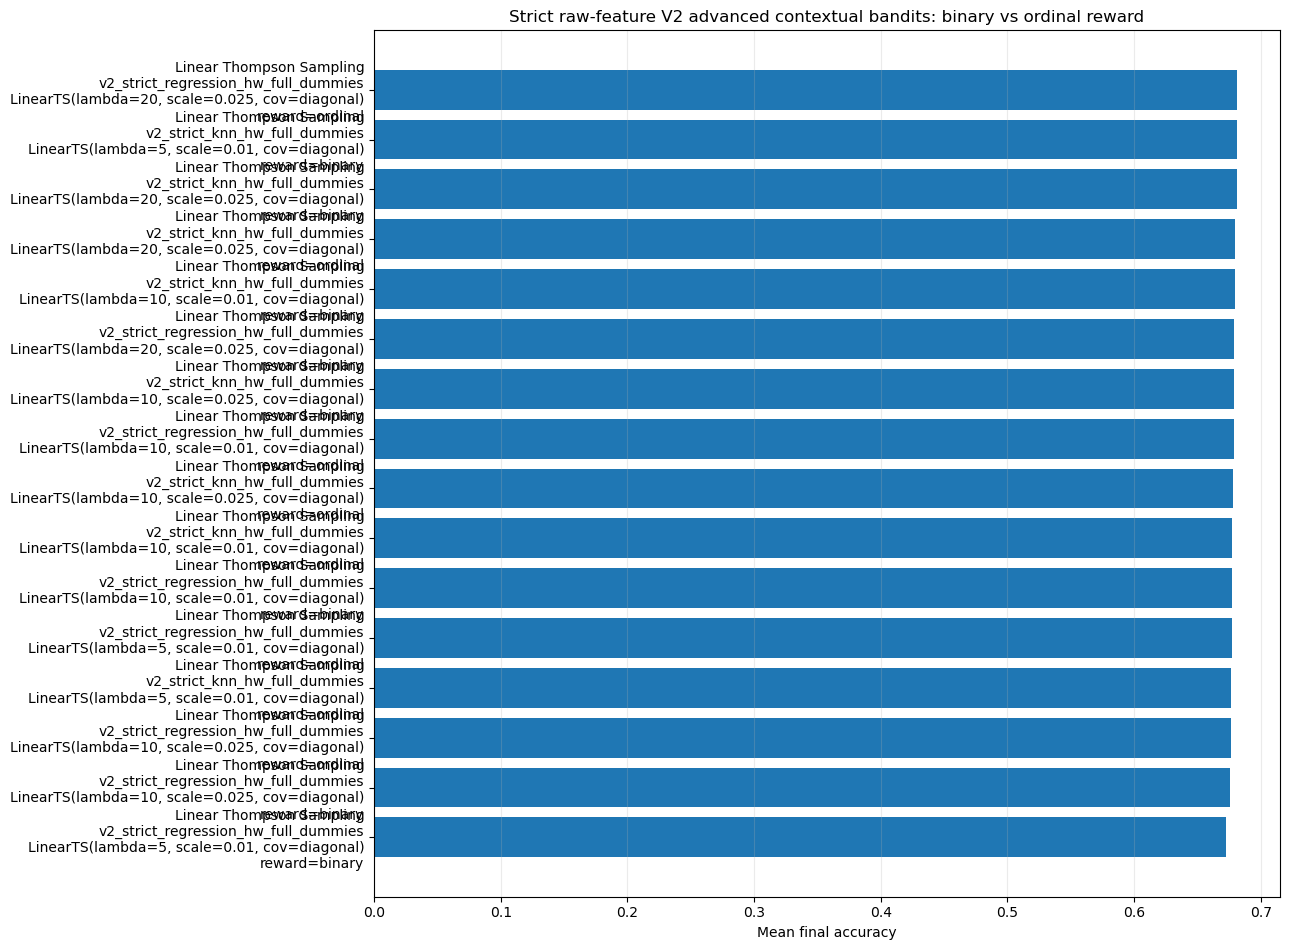

In [13]:
fig, ax = plot_advanced_leaderboard(
    advanced_summary,
    top_n=16,
    title='Strict raw-feature V2 advanced contextual bandits: binary vs ordinal reward',
)
fig.savefig(RESULTS_DIR / 'advanced_bandit_reward_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Reward comparison checkpoint

In [14]:
comparison_cols = [
    'algorithm_family', 'reward_scheme', 'feature_set', 'config_name',
    'final_accuracy_mean', 'final_accuracy_ci95', 'final_reward_mean',
    'late_accuracy_mean', 'final_regret_mean',
]
advanced_summary[comparison_cols].sort_values('final_accuracy_mean', ascending=False).head(30)

,algorithm_family,reward_scheme,feature_set,config_name,final_accuracy_mean,final_accuracy_ci95,final_reward_mean,late_accuracy_mean,final_regret_mean
0,Linear Thompson Sampling,ordinal,v2_strict_regression_hw_full_dummies,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",0.681138,0.000775,0.679088,0.686667,1774.000000
1,Linear Thompson Sampling,binary,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",0.680897,0.003492,0.680897,0.704667,1764.000000
2,Linear Thompson Sampling,binary,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",0.680897,0.005979,0.680897,0.695333,1764.000000
3,Linear Thompson Sampling,ordinal,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",0.679993,0.002677,0.678003,0.687333,1780.000000
4,Linear Thompson Sampling,binary,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.679872,0.003440,0.679872,0.690000,1769.666667
5,Linear Thompson Sampling,binary,v2_strict_regression_hw_full_dummies,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",0.679149,0.005842,0.679149,0.682000,1773.666667
6,Linear Thompson Sampling,binary,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",0.678787,0.003891,0.678787,0.696000,1775.666667
7,Linear Thompson Sampling,ordinal,v2_strict_regression_hw_full_dummies,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.678726,0.001749,0.676556,0.686000,1788.000000
8,Linear Thompson Sampling,ordinal,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",0.678003,0.002866,0.675953,0.688667,1791.333333
9,Linear Thompson Sampling,ordinal,v2_strict_knn_hw_full_dummies,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.677641,0.002866,0.675591,0.695333,1793.333333


## 8. Coefficient audit for best LinearTS and LassoLinUCB

This fits one final online pass for the best LinearTS and LassoLinUCB configurations and saves coefficient/group summaries, including clinical-signal views that filter out missingness/intercept features.


In [15]:
def linear_ts_factory_from_row(row):
    return lambda n_arms, n_features: LinearThompsonSampling(
        n_arms=n_arms,
        n_features=n_features,
        lambda_reg=float(row['lambda_reg']),
        sample_scale=float(row['sample_scale']),
        covariance_type=row['covariance_type'],
        random_state=0,
    )


def lasso_factory_from_row(row):
    def factory(n_arms, n_features, feature_cols=None):
        intercept_index = get_intercept_index(feature_cols or [])
        return LassoLinUCB(
            n_arms=n_arms,
            n_features=n_features,
            lasso_alpha=float(row['lasso_alpha']),
            ucb_alpha=float(row['ucb_alpha']),
            lambda_reg=float(row['lambda_reg']),
            min_samples_per_arm=int(row['min_samples_per_arm']),
            refit_frequency=int(row['refit_frequency']),
            intercept_index=intercept_index,
            random_state=0,
        )
    return factory


best_ts = ts_summary.sort_values('final_accuracy_mean', ascending=False).iloc[0]
best_lasso = lasso_summary.sort_values('final_accuracy_mean', ascending=False).iloc[0]

audit_specs = [
    ('best_linear_ts', best_ts, linear_ts_factory_from_row(best_ts)),
    ('best_lasso_linucb', best_lasso, lasso_factory_from_row(best_lasso)),
]

advanced_audits = {}
for prefix, row, factory in audit_specs:
    audit = audit_bandit_coefficients(
        bandit_factory=factory,
        df=df_v2,
        feature_sets=feature_sets,
        feature_set_name=row['feature_set'],
        algorithm=row['config_name'],
        seed=0,
        reward_scheme=row['reward_scheme'],
        standardize=True,
        coefficient_mode='effective',
        top_n=30,
    )
    save_coefficient_audit(AUDIT_DIR, prefix, audit, save_full_coefficients=True, save_run=False)
    advanced_audits[prefix] = audit

{key: audit['summary'] for key, audit in advanced_audits.items()}

{'best_linear_ts':                                         algorithm  \
 0  LinearTS(lambda=20, scale=0.025, cov=diagonal)   
 
                             feature_set reward_scheme  seed  n_features  \
 0  v2_strict_regression_hw_full_dummies       ordinal     0         295   
 
    final_accuracy  final_mean_reward  
 0         0.68144           0.679269  ,
 'best_lasso_linucb':                                            algorithm  \
 0  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...   
 
                             feature_set reward_scheme  seed  n_features  \
 0  v2_strict_regression_hw_full_dummies        binary     0         295   
 
    final_accuracy  final_mean_reward  
 0        0.669139           0.669139  }

In [16]:
advanced_audits['best_linear_ts']['feature_group_summary'].head(30)

,algorithm,feature_set,reward_scheme,coefficient_mode,arm_id,arm_name,feature_group,n_features,mean_abs_coefficient,max_abs_coefficient,l1_mass
3,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,genotype,104,0.023729,0.082330,2.467786
9,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,missingness_unknown,72,0.026194,0.102015,1.885954
8,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,medication_text_or_flag,34,0.032263,0.107636,1.096928
1,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,comorbidity_text_or_flag,19,0.043125,0.087822,0.819373
6,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,interaction,21,0.020434,0.078871,0.429111
10,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,other,15,0.022439,0.082280,0.336584
5,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,indication,10,0.031042,0.068366,0.310423
4,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,height_weight,4,0.036310,0.065860,0.145242
12,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,target_inr,9,0.015975,0.049485,0.143773
0,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,age,1,0.089555,0.089555,0.089555


In [17]:
advanced_audits['best_lasso_linucb']['feature_group_summary'].head(30)

,algorithm,feature_set,reward_scheme,coefficient_mode,arm_id,arm_name,feature_group,n_features,mean_abs_coefficient,max_abs_coefficient,l1_mass
9,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,missingness_unknown,72,0.008058,0.192034,0.580172
6,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,interaction,21,0.016637,0.151343,0.349373
1,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,comorbidity_text_or_flag,19,0.014392,0.115991,0.273445
3,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,genotype,104,0.002169,0.068849,0.225614
7,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,intercept,1,0.204148,0.204148,0.204148
10,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,other,15,0.010755,0.130202,0.161320
4,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,height_weight,4,0.027713,0.080046,0.110851
5,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,indication,10,0.007285,0.040253,0.072850
8,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,medication_text_or_flag,34,0.001408,0.029181,0.047879
2,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,0,low,gender,2,0.011190,0.022380,0.022380


In [18]:
advanced_audits['best_linear_ts']['clinical_contrasts'].head(30)

arm_id,algorithm,feature_set,reward_scheme,coefficient_mode,feature,feature_group,contrast,arm_id,baseline_arm_id,coefficient_difference,abs_coefficient_difference
0,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Interaction__BSA_x_VKORC1_Acount__regression_hw,interaction,high_minus_medium,2,1,-0.387301,0.387301
1,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Interaction__AgeDecade_x_VKORC1_Acount,interaction,high_minus_medium,2,1,0.272023,0.272023
2,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Weight (kg)__regression,height_weight,high_minus_medium,2,1,0.258820,0.258820
3,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Interaction__Weight_x_CYP2C9Reduced__regressio...,interaction,high_minus_medium,2,1,-0.153696,0.153696
4,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Age__mode_decade,age,high_minus_medium,2,1,-0.144644,0.144644
5,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Diabetes_Yes,comorbidity_text_or_flag,high_minus_medium,2,1,-0.131733,0.131733
6,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,TargetINR__any_available,target_inr,high_minus_medium,2,1,-0.128789,0.128789
7,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,VKORC1 genotype: -1639 G>A (3673); chr16:31015...,genotype,high_minus_medium,2,1,-0.119138,0.119138
8,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,VKORC1_rs9923231__A_count,genotype,high_minus_medium,2,1,0.108771,0.108771
9,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,Amiodarone (Cordarone),medication_text_or_flag,high_minus_medium,2,1,-0.107968,0.107968


In [19]:
advanced_audits['best_lasso_linucb']['clinical_contrasts'].head(30)

arm_id,algorithm,feature_set,reward_scheme,coefficient_mode,feature,feature_group,contrast,arm_id,baseline_arm_id,coefficient_difference,abs_coefficient_difference
0,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Interaction__BSA_x_VKORC1_Acount__regression_hw,interaction,high_minus_medium,2,1,-0.356058,0.356058
1,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Indication__Cardiomyopathy_or_LV_Dilation,indication,high_minus_medium,2,1,-0.338179,0.338179
2,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Interaction__AgeDecade_x_VKORC1_Acount,interaction,high_minus_medium,2,1,0.314680,0.314680
3,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,VKORC1 genotype: 3730 G>A (9041); chr16:310098...,genotype,high_minus_medium,2,1,0.232227,0.232227
4,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,MedicationText__statin,medication_text_or_flag,high_minus_medium,2,1,0.187461,0.187461
5,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Race_Black or African American,race,high_minus_medium,2,1,-0.186454,0.186454
6,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Ethnicity_Hispanic or Latino,other,high_minus_medium,2,1,-0.175666,0.175666
7,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,VKORC1 QC genotype: -4451 C>A (861); Chr16:310...,genotype,high_minus_medium,2,1,-0.168316,0.168316
8,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Indication__DVT,indication,high_minus_medium,2,1,0.150538,0.150538
9,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",v2_strict_regression_hw_full_dummies,binary,effective,Comorbidity__cancer,comorbidity_text_or_flag,high_minus_medium,2,1,0.144591,0.144591


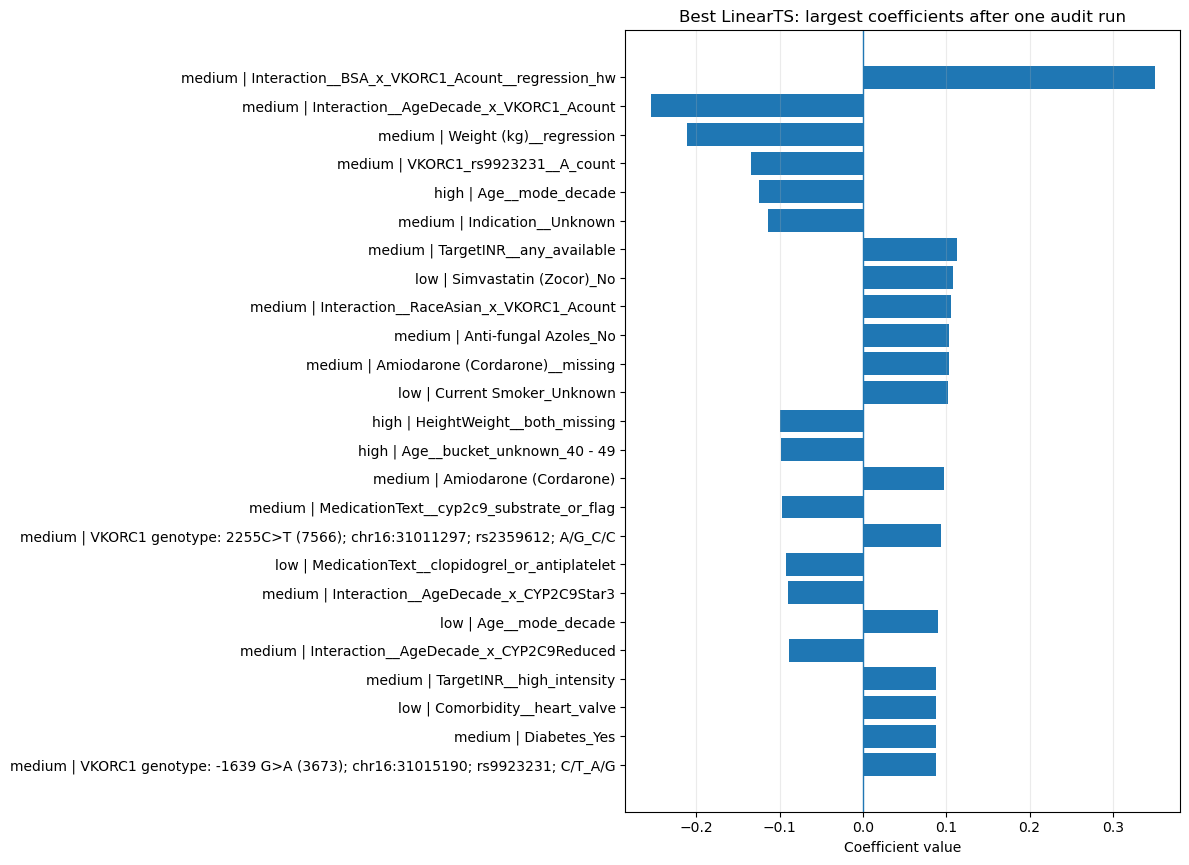

In [20]:
fig, ax = plot_top_coefficients(
    advanced_audits['best_linear_ts']['top_coefficients'],
    title='Best LinearTS: largest coefficients after one audit run',
    top_n=25,
)
fig.savefig(AUDIT_DIR / 'best_linear_ts_top_coefficients.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Coefficient model cards for the selected advanced policies

These cards read the complete coefficient CSVs saved by the seed-0 audit pass and therefore do not rerun either bandit. A weight is counted as non-zero when its absolute value exceeds `1e-12`. This threshold exposes LassoLinUCB's structural sparsity, while Linear Thompson Sampling remains a mostly dense linear policy whose small coefficients are shrunk rather than selected away.

The values are the final arm-specific posterior means or regression coefficients after the audit stream, not causal effects. They are specific to the selected feature set, reward scheme, standardization, and seed. Non-binary inputs were standardized before fitting, while binary indicators and the intercept retained their original scale. The full exported cards preserve all 295 features; the displays below focus on arm-level counts, support overlap, and the strongest signed weights.

In [4]:
from IPython.display import display

MODEL_CARD_ZERO_TOLERANCE = 1e-12
MODEL_CARD_TOP_N = 10

def build_saved_coefficient_card(prefix):
    coefficients = pd.read_csv(AUDIT_DIR / f'{prefix}_coefficients.csv')
    card = coefficient_model_card(
        coefficients,
        zero_tolerance=MODEL_CARD_ZERO_TOLERANCE,
        top_n=MODEL_CARD_TOP_N,
    )
    paths = save_coefficient_model_card(AUDIT_DIR, prefix, card)
    return coefficients, card, paths

lasso_coefficients, lasso_model_card, lasso_model_card_paths = build_saved_coefficient_card(
    'best_lasso_linucb'
)
linear_ts_coefficients, linear_ts_model_card, linear_ts_model_card_paths = build_saved_coefficient_card(
    'best_linear_ts'
)

print('LassoLinUCB model-card files:', lasso_model_card_paths)
print('LinearTS model-card files:', linear_ts_model_card_paths)

LassoLinUCB model-card files: {'summary': PosixPath('/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/coefficient_audit/best_lasso_linucb_model_card_summary.csv'), 'top_weights': PosixPath('/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/coefficient_audit/best_lasso_linucb_model_card_top_weights.csv'), 'coefficients_wide': PosixPath('/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/coefficient_audit/best_lasso_linucb_model_card_coefficients_wide.csv'), 'support_patterns': PosixPath('/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/coefficient_audit/best_lasso_linucb_model_card_support_patterns.csv')}
LinearTS model-card files: {'summary': PosixPath('/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/coefficient_audit/best_linear_ts_model_card_summary.csv'), 'top_weights': PosixPath('/Users/dhillo/Garage/codeComplet

In [5]:
advanced_model_card_summary = pd.concat([
    lasso_model_card['summary'].assign(model_card='LassoLinUCB arm weights'),
    linear_ts_model_card['summary'].assign(model_card='LinearTS posterior-mean arm weights'),
], ignore_index=True)

summary_columns = [
    'model_card', 'arm_name', 'n_features', 'n_nonzero', 'n_zero',
    'nonzero_fraction', 'n_positive', 'n_negative', 'l1_norm', 'l2_norm',
    'strongest_positive_feature', 'strongest_positive_coefficient',
    'strongest_negative_feature', 'strongest_negative_coefficient',
]
advanced_model_card_summary[summary_columns]

,model_card,arm_name,n_features,n_nonzero,n_zero,nonzero_fraction,n_positive,n_negative,l1_norm,l2_norm,strongest_positive_feature,strongest_positive_coefficient,strongest_negative_feature,strongest_negative_coefficient
0,LassoLinUCB arm weights,low,295,47,248,0.159322,25,22,2.068961,0.443750,Intercept,0.204148,Was Dose of Acetaminophen or Paracetamol (Tyle...,-0.130202
1,LassoLinUCB arm weights,medium,295,54,241,0.183051,23,31,2.216130,0.752682,Intercept,0.659101,Interaction__AgeDecade_x_VKORC1_Acount,-0.224379
2,LassoLinUCB arm weights,high,295,72,223,0.244068,36,36,4.973168,0.795498,VKORC1 genotype: 3730 G>A (9041); chr16:310098...,0.232227,Indication__Cardiomyopathy_or_LV_Dilation,-0.338179
3,LinearTS posterior-mean arm weights,low,295,273,22,0.925424,136,137,7.825158,0.602315,Simvastatin (Zocor)_No,0.107636,MedicationText__clopidogrel_or_antiplatelet,-0.092493
4,LinearTS posterior-mean arm weights,medium,295,295,0,1.000000,164,131,9.293459,0.808783,Interaction__BSA_x_VKORC1_Acount__regression_hw,0.350284,Interaction__AgeDecade_x_VKORC1_Acount,-0.254841
5,LinearTS posterior-mean arm weights,high,295,262,33,0.888136,120,142,6.033108,0.488409,Interaction__CurrentSmoker_x_AgeDecade,0.081271,Age__mode_decade,-0.124508


In [6]:
for model_name, card in [
    ('LassoLinUCB arm weights', lasso_model_card),
    ('LinearTS posterior-mean arm weights', linear_ts_model_card),
]:
    print(f'\n{model_name}: non-zero support patterns')
    display(card['support_patterns'])
    print(f'{model_name}: strongest positive and negative weights')
    display(card['top_weights'][[
        'arm_name', 'direction', 'rank', 'feature', 'feature_group', 'coefficient'
    ]])
    print(f'{model_name}: first 30 rows of the complete feature-by-arm card')
    display(card['coefficients_wide'].head(30))


LassoLinUCB arm weights: non-zero support patterns


,nonzero_arm_pattern,n_nonzero_arms,n_features,zero_tolerance
0,low+medium+high,3,10,1.000000e-12
1,medium+high,2,16,1.000000e-12
2,low+medium,2,10,1.000000e-12
3,low+high,2,5,1.000000e-12
4,high,1,41,1.000000e-12
5,low,1,22,1.000000e-12
6,medium,1,18,1.000000e-12
7,none,0,173,1.000000e-12


LassoLinUCB arm weights: strongest positive and negative weights


,arm_name,direction,rank,feature,feature_group,coefficient
0,low,negative,1,Was Dose of Acetaminophen or Paracetamol (Tyle...,other,-0.130202
1,low,negative,2,Comorbidity__diabetes,comorbidity_text_or_flag,-0.115991
2,low,negative,3,BSA_Mosteller__regression_hw,height_weight,-0.080046
3,low,negative,4,Height (cm)__missing,missingness_unknown,-0.062322
4,low,negative,5,Congestive Heart Failure and/or Cardiomyopathy_No,comorbidity_text_or_flag,-0.062123
5,low,negative,6,VKORC1 -1639 consensus_Unknown,missingness_unknown,-0.054236
6,low,negative,7,Amiodarone (Cordarone)__missing,missingness_unknown,-0.044357
7,low,negative,8,Indication__DVT,indication,-0.040253
8,low,negative,9,VKORC1 genotype: 497T>G (5808); chr16:31013055...,missingness_unknown,-0.040241
9,low,negative,10,Height (cm)__regression,height_weight,-0.030805


LassoLinUCB arm weights: first 30 rows of the complete feature-by-arm card


...

,nonzero_arm_pattern,n_nonzero_arms,n_features,zero_tolerance
0,low+medium+high,3,255,1.000000e-12
1,low+medium,2,18,1.000000e-12
2,medium+high,2,7,1.000000e-12
3,medium,1,15,1.000000e-12


LinearTS posterior-mean arm weights: strongest positive and negative weights


,arm_name,direction,rank,feature,feature_group,coefficient
0,low,negative,1,MedicationText__clopidogrel_or_antiplatelet,medication_text_or_flag,-0.092493
1,low,negative,2,Simvastatin (Zocor)_Yes,medication_text_or_flag,-0.082806
2,low,negative,3,Current Smoker_No,other,-0.082280
3,low,negative,4,VKORC1_rs9923231__G_count,genotype,-0.079771
4,low,negative,5,Diabetes_Yes,comorbidity_text_or_flag,-0.068630
5,low,negative,6,Ethnicity_Unknown,missingness_unknown,-0.068517
6,low,negative,7,Indication__PE,indication,-0.068366
7,low,negative,8,Age__bucket_unknown_30 - 39,missingness_unknown,-0.068359
8,low,negative,9,Atorvastatin (Lipitor)_No,medication_text_or_flag,-0.067763
9,low,negative,10,MedicationText__none_reported,medication_text_or_flag,-0.066487


LinearTS posterior-mean arm weights: first 30 rows of the complete feature-by-arm card


,algorithm,feature_set,reward_scheme,coefficient_mode,feature_index,feature,feature_group,low_coefficient,medium_coefficient,high_coefficient,low_nonzero,medium_nonzero,high_nonzero,n_nonzero_arms,nonzero_arm_pattern,max_abs_coefficient,zero_tolerance
0,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,94,Interaction__BSA_x_VKORC1_Acount__regression_hw,interaction,-0.004502,0.350284,-0.037016,True,True,True,3,low+medium+high,0.350284,1.000000e-12
1,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,77,Interaction__AgeDecade_x_VKORC1_Acount,interaction,0.061977,-0.254841,0.017182,True,True,True,3,low+medium+high,0.254841,1.000000e-12
2,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,74,Weight (kg)__regression,height_weight,-0.034848,-0.211233,0.047587,True,True,True,3,low+medium+high,0.211233,1.000000e-12
3,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,67,VKORC1_rs9923231__A_count,genotype,0.044608,-0.134253,-0.025483,True,True,True,3,low+medium+high,0.134253,1.000000e-12
4,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,5,Age__mode_decade,age,0.089555,0.020136,-0.124508,True,True,True,3,low+medium+high,0.124508,1.000000e-12
5,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,19,Indication__Unknown,missingness_unknown,-0.020374,-0.113921,-0.033013,True,True,True,3,low+medium+high,0.113921,1.000000e-12
6,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,24,TargetINR__any_available,target_inr,-0.037800,0.113278,-0.015511,True,True,True,3,low+medium+high,0.113278,1.000000e-12
7,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,126,Simvastatin (Zocor)_No,medication_text_or_flag,0.107636,0.048695,-0.037407,True,True,True,3,low+medium+high,0.107636,1.000000e-12
8,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,83,Interaction__RaceAsian_x_VKORC1_Acount,interaction,0.012842,0.106064,0.006058,True,True,True,3,low+medium+high,0.106064,1.000000e-12
9,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",v2_strict_regression_hw_full_dummies,ordinal,effective,152,Anti-fungal Azoles_No,other,-0.015080,0.103838,-0.001995,True,True,True,3,low+medium+high,0.103838,1.000000e-12
